# NB4: Model Performance on Edge Years

Load the trained XGBoost model and scaler from NB3. Apply them to data from edge years 
(before and after the training period) to evaluate how well the model generalizes to 
out-of-distribution time periods.

In [ ]:
# ============================================================
# Colab setup — run this cell FIRST. Does nothing when run locally.
# ============================================================
import os, sys, shutil

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1) Clone repo (or pull if already cloned)
    if not os.path.exists("/content/ML_TND"):
        os.system("git clone -q https://github.com/lotteat11/ML_TND /content/ML_TND")
    else:
        os.system("cd /content/ML_TND && git pull -q")

    # 2) Install Python deps
    os.system("pip install -q xgboost scikit-learn pyarrow joblib")

    # 3) Download parquet from GitHub Releases (wget follows redirects reliably)
    dest = "/content/ML_TND/grace_workshop_small.parquet"
    MIN_SIZE = 200 * 1024 * 1024  # 200 MB — valid file is ~257 MB
    if os.path.exists(dest) and os.path.getsize(dest) < MIN_SIZE:
        print(f"Parquet incomplete ({os.path.getsize(dest)//1024//1024} MB) — re-downloading...")
        os.remove(dest)
    if not os.path.exists(dest):
        print("Downloading grace_workshop_small.parquet (~257 MB)...")
        ret = os.system(
            f"wget -q --show-progress -O {dest} "
            "https://github.com/lotteat11/ML_TND/releases/download/v1.0-workshop/grace_workshop_small.parquet"
        )
        if ret != 0 or not os.path.exists(dest) or os.path.getsize(dest) < MIN_SIZE:
            if os.path.exists(dest): os.remove(dest)
            raise RuntimeError("Download failed or incomplete. Check your internet connection and re-run this cell.")
        print("Download complete.")

    # 4) chdir into workshop/ so all relative paths resolve
    os.chdir("/content/ML_TND/workshop")
    print("Setup complete — ready to run.")
else:
    print("Local run — no setup needed.")


In [40]:
%pip install -q xgboost scikit-learn pandas numpy matplotlib scipy joblib pyarrow


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Import Required Libraries

In [41]:
import sys, joblib
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import feature_functions as ff
from paths import GRACE_WORKSHOP as GRACE_MERGED

## 2. Load Data and Feature Engineering

Load the full GRACE dataset and apply the same feature engineering pipeline as NB3.

In [42]:
# Load the FULL dataset (not filtered like NB3)
df_full = pd.read_parquet(GRACE_MERGED)
df_full['time'] = pd.to_datetime(df_full['grace_time'])
df_full = df_full.sort_values('time').reset_index(drop=True)
df_full = df_full[(df_full['rho_obs'] > 0) & (df_full['msis_rho'] > 0)].reset_index(drop=True)
df_full['log_ratio'] = np.log(df_full['rho_obs'] / df_full['msis_rho'])

# Apply feature engineering
df_full = ff.add_lst_doy_features(df_full)
df_full['lon_sin']           = np.sin(np.deg2rad(df_full['lon']))
df_full['lon_cos']           = np.cos(np.deg2rad(df_full['lon']))
df_full['lst_lat_sin']       = df_full['lst_sin'] * df_full['lat']
df_full['vtec_matched_lag']  = df_full['matched_tec_value'].shift(500)
df_full['vtec_matched_lag2'] = df_full['matched_tec_value'].shift(17280)
df_full = df_full.dropna().reset_index(drop=True)

# Define features used in NB3
FEATURES = ['f107', 'f107a', 'ap_m3h', 'ap_m6h', 'alt_km', 'lat',
            'matched_tec_value', 'lst_sin', 'lst_cos', 'doy_sin', 'doy_cos',
            'lon_sin', 'lon_cos', 'vtec_matched_lag', 'vtec_matched_lag2', 'lst_lat_sin']
COLS_TO_SCALE = ['f107', 'f107a', 'ap_m3h', 'ap_m6h', 'alt_km', 'lat',
                 'matched_tec_value', 'vtec_matched_lag', 'vtec_matched_lag2']
TARGET = 'log_ratio'

print(f'Loaded {len(df_full):,} rows (full time range)')
print(f'Time range: {df_full["time"].min()} to {df_full["time"].max()}')

Loaded 7,070,334 rows (full time range)
Time range: 2009-01-02 00:00:00+00:00 to 2016-03-31 23:59:50+00:00


## 3. Load Trained Model and Scaler from NB3

In [43]:
# Load the trained cyclic-split model and scaler
scaler = joblib.load("nb3_scaler_cyclic.joblib")
model = xgb.XGBRegressor()
model.load_model("nb3_model_cyclic.json")

print("Loaded trained model and scaler from NB3")
print(f"Model type: {type(model)}")
print(f"Scaler type: {type(scaler)}")

Loaded trained model and scaler from NB3
Model type: <class 'xgboost.sklearn.XGBRegressor'>
Scaler type: <class 'sklearn.preprocessing._data.MinMaxScaler'>


### Extract the edge years

The core model was trained on mid-2009 to 2015. We now evaluate it on two periods that were **completely excluded from training** — these are the strictest test of generalisation:

| Period | Conditions | Why it's hard |
|---|---|---|
| **Pre-2009** (Jan–May 2009) | **Quiet** — solar minimum, low geomagnetic activity, GRACE at ~476 km | Density is very low; MSIS R² is negative (−0.90) because small absolute errors dominate |
| **Post-2016** (Jan–Mar 2016) | **Disturbed** — solar active, includes the 18 Feb 2016 storm, GRACE at ~381 km | Rapid storm-time variability that empirical models struggle to capture |

This contrast — quiet vs disturbed — directly mirrors the paper's Table 2 and is the key validation of the warm-start strategy.

In [44]:
# Define the NB3 training period
# Remove timezone info for comparison if it exists
df_full['time_naive'] = df_full['time'].dt.tz_localize(None) if df_full['time'].dt.tz is not None else df_full['time']

TRAIN_START = pd.Timestamp('2009-06-01')
TRAIN_END   = pd.Timestamp('2016-01-01')

# Extract edge years (before and after)
df_before = df_full[df_full['time_naive'] < TRAIN_START].copy()
df_after  = df_full[df_full['time_naive'] >= TRAIN_END].copy()

print(f"Data before training period: {len(df_before):,} rows ({df_before['time'].min()} to {df_before['time'].max()})")
print(f"Data after training period:  {len(df_after):,} rows ({df_after['time'].min()} to {df_after['time'].max()})")
print(f"Total edge years data: {len(df_before) + len(df_after):,} rows")

# Combine for analysis
df_edges = pd.concat([df_before, df_after], ignore_index=False).sort_values('time')
print(f"\nEdge years combined: {len(df_edges):,} rows")

Data before training period: 1,525,871 rows (2009-01-02 00:00:00+00:00 to 2009-03-31 23:59:50+00:00)
Data after training period:  1,560,014 rows (2016-01-01 00:00:00+00:00 to 2016-03-31 23:59:50+00:00)
Total edge years data: 3,085,885 rows

Edge years combined: 3,085,885 rows


## 5. Apply Model to Edge Years

Scale the features using the trained scaler and make predictions.

In [45]:
# Prepare features for edge years
X_edges = df_edges[FEATURES].copy()

# Scale using the trained scaler
X_edges_scaled = X_edges.copy()
X_edges_scaled[COLS_TO_SCALE] = scaler.transform(X_edges[COLS_TO_SCALE])

# Make predictions in log-space
y_edges_pred_log = model.predict(X_edges_scaled)

# Convert to physical density space: rho = msis_rho * exp(log_ratio)
rho_msis = df_edges['msis_rho'].values
rho_obs = df_edges['rho_obs'].values
rho_pred = rho_msis * np.exp(y_edges_pred_log)

# Store in dataframe for later use
df_edges['rho_pred'] = rho_pred
df_edges['y_pred_log'] = y_edges_pred_log

# Also add predictions back to df_before and df_after using index alignment
df_before['rho_pred'] = df_before.index.map(df_edges.set_index(df_edges.index)['rho_pred'])
df_after['rho_pred'] = df_after.index.map(df_edges.set_index(df_edges.index)['rho_pred'])

print(f"Made predictions for {len(df_edges):,} edge years samples")
print(f"Prediction range: {rho_pred.min():.3e} to {rho_pred.max():.3e} kg/m³")

Made predictions for 3,085,885 edge years samples
Prediction range: 2.563e-14 to 6.386e-12 kg/m³


## 6. Evaluate Model Performance on Edge Years

In [46]:
# Summary by period
print("\nPeriod-by-period breakdown:")
for period_name, df_period in [("Pre-2009", df_before), ("Post-2016", df_after)]:
    if len(df_period) > 0:
        rho_obs_p = df_period['rho_obs'].values
        rho_pred_p = df_period['rho_pred'].values
        rho_msis_p = df_period['msis_rho'].values
        mask_p = (rho_obs_p > 0) & (rho_pred_p > 0) & (rho_msis_p > 0)
        if mask_p.sum() > 0:
            rmse_p = np.sqrt(np.mean((rho_obs_p[mask_p] - rho_pred_p[mask_p]) ** 2))
            rmse_msis_p = np.sqrt(np.mean((rho_obs_p[mask_p] - rho_msis_p[mask_p]) ** 2))
            r2_p = r2_score(rho_obs_p[mask_p], rho_pred_p[mask_p])
            r2_msis_p = r2_score(rho_obs_p[mask_p], rho_msis_p[mask_p])
            improvement = (rmse_msis_p - rmse_p) / rmse_msis_p * 100
            print(f"\n  {period_name} ({mask_p.sum():,} samples):")
            print(f"    MSIS RMSE:  {rmse_msis_p:.3e} kg/m³")
            print(f"    Model RMSE: {rmse_p:.3e} kg/m³  (improvement: {improvement:+.1f}%)")
            print(f"    Model R²:   {r2_p:.4f}  vs MSIS R²: {r2_msis_p:.4f}")


Period-by-period breakdown:

  Pre-2009 (1,525,871 samples):
    MSIS RMSE:  7.030e-14 kg/m³
    Model RMSE: 5.090e-14 kg/m³  (improvement: +27.6%)
    Model R²:   0.1646  vs MSIS R²: -0.5939

  Post-2016 (1,560,014 samples):
    MSIS RMSE:  5.245e-13 kg/m³
    Model RMSE: 4.309e-13 kg/m³  (improvement: +17.8%)
    Model R²:   0.8584  vs MSIS R²: 0.7902


## 7. Visualize Predictions vs Observations

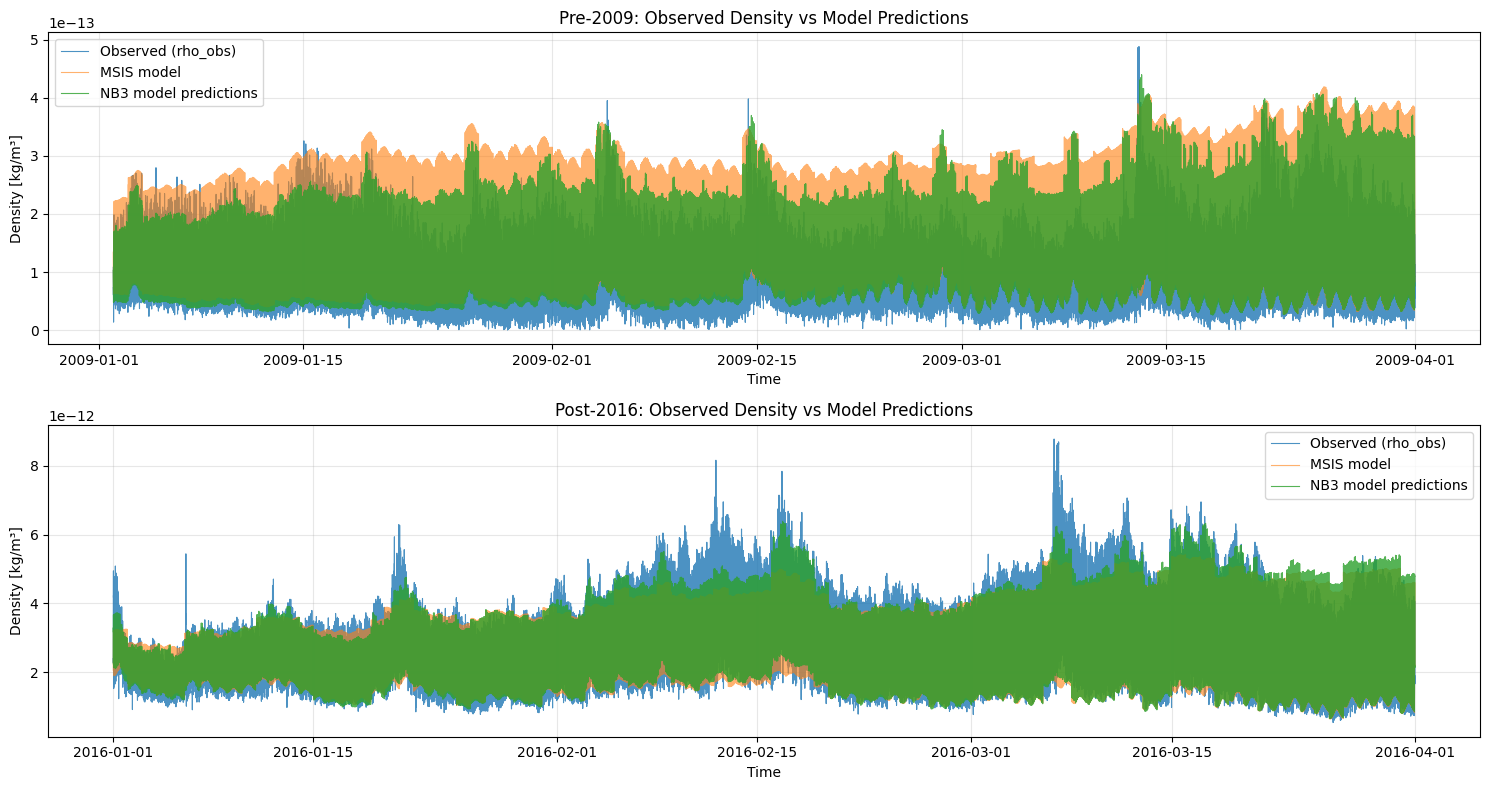

In [47]:
# Edge-year predictions — time series (top) and parity scatter (bottom)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

periods = [
    ('Pre-2009',  df_before, 'rho_pred'),
    ('Post-2016', df_after,  'rho_pred'),
]

for col_idx, (label, df_p, pred_col) in enumerate(periods):
    if len(df_p) == 0:
        continue
    t = df_p['time'].dt.tz_localize(None) if df_p['time'].dt.tz is not None else df_p['time']
    obs  = df_p['rho_obs'].values
    msis = df_p['msis_rho'].values
    pred = df_p[pred_col].values

    # Top row: time series (every 5th point for speed)
    ax = axes[0, col_idx]
    ax.plot(t.values[::5], obs[::5],  lw=0.5, label='Observed', color='black')
    ax.plot(t.values[::5], msis[::5], lw=0.5, label='MSIS',     color='C1', alpha=0.8)
    ax.plot(t.values[::5], pred[::5], lw=0.5, label='Predicted',color='C0', alpha=0.9)
    ax.set_yscale('log')
    ax.set_ylabel('ρ [kg m⁻³]')
    ax.set_title(f'{label} — density vs time')
    ax.legend(fontsize=7)

    # Bottom row: parity scatter
    ax = axes[1, col_idx]
    mask = (obs > 0) & (pred > 0) & (msis > 0)
    o, p, m = obs[mask][::5], pred[mask][::5], msis[mask][::5]
    lim = [min(o.min(), p.min(), m.min()), max(o.max(), p.max(), m.max())]
    ax.scatter(o, m, s=1, alpha=0.2, color='C1', label='MSIS',      rasterized=True)
    ax.scatter(o, p, s=1, alpha=0.2, color='C0', label='Predicted',  rasterized=True)
    ax.plot(lim, lim, 'k--', lw=0.8)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Observed ρ [kg m⁻³]')
    ax.set_ylabel('Predicted / MSIS ρ [kg m⁻³]')
    ax.set_title(f'{label} — parity')
    ax.legend(fontsize=7, markerscale=4)

plt.tight_layout()
plt.show()


## Summary

The NB3 model trained on the 2009-06-01 to 2016-01-01 period has been applied to edge years data 
(before and after the training period). This tests how well the model generalizes to out-of-distribution 
time periods with potentially different atmospheric conditions.

**Key Observations:**
- Model performance on edge years gives insight into temporal generalization
- Residual plots help identify systematic biases or failure modes
- Comparison with MSIS baseline shows the value of the learned model

## 8. Warm-Start Rolling Forecast (5-day lookback → 3-day forecast)

This is the proper warm-start forecasting scheme from the paper (`Forecast/on_track.py`).

For each forecast day, we **fine-tune the base model on the previous 5 days** (the lookback
window), then **forecast the next 3 days** (the horizon). We advance one day at a time, so every
forecast is made on data the model has *not* seen during that step's fine-tuning.

Because the fine-tune window always sits **immediately before** the forecast window, recent
space-weather conditions carry into the forecast — this is why warm-start beats plain MSIS.

We evaluate on the post-2016 edge period (out-of-distribution for the NB3 model) and report the
same metrics as the paper: RMSE, Top-5% error, MAPE and R² in both linear and log density space.

In [ ]:
# Warm-start rolling forecast: fine-tune on previous LOOKBACK days, forecast next HORIZON days
import copy

# ---------------- CONFIG ----------------
LOOKBACK_DAYS    = 5      # days of recent data to fine-tune on
FORECAST_HORIZON = 3      # days ahead to forecast each step
RESET_EVERY      = 3      # reset to the original model every N steps (lower = less drift)
FINETUNE_ROUNDS  = 100    # max extra trees added per warm-start step (lower = less overfit/drift)
EDGE_PERIOD      = "post2016"   # "post2016" or "pre2009"
EVAL_WEEKS       = None   # limit to first N weeks of edge period (None = all); set e.g. 1 for a quick test
# ----------------------------------------

# Choose the edge dataframe (already feature-engineered as df_before / df_after in section 4)
df_edge = df_after.copy() if EDGE_PERIOD == "post2016" else df_before.copy()
df_edge["time"] = pd.to_datetime(df_edge["time"])
df_edge["date"] = df_edge["time"].dt.date
df_edge = df_edge.sort_values("time").reset_index(drop=True)

unique_dates = sorted(df_edge["date"].unique())

# Optionally restrict to the first EVAL_WEEKS weeks (keep LOOKBACK_DAYS of history before the first forecast)
if EVAL_WEEKS is not None:
    n_keep = LOOKBACK_DAYS + EVAL_WEEKS * 7
    unique_dates = unique_dates[:n_keep]
    df_edge = df_edge[df_edge["date"].isin(unique_dates)].reset_index(drop=True)
    print(f"(EVAL_WEEKS={EVAL_WEEKS}: limited to first {len(unique_dates)} days)")

print(f"Edge period '{EDGE_PERIOD}': {len(df_edge):,} rows over {len(unique_dates)} days")
print(f"  {unique_dates[0]} → {unique_dates[-1]}")
print(f"Rolling forecast: {LOOKBACK_DAYS}-day lookback → {FORECAST_HORIZON}-day horizon\n")


def lr_scheduler_ws(current_round):
    """Low LR for the first few rounds, then exponential decay (matches on_track.py)."""
    initial_lr = 0.03
    if current_round < 4:
        initial_lr = 1e-7
    return initial_lr * (0.9 ** (current_round // 12))


def finetune_on_window(base_booster, train_df):
    """Warm-start the booster on train_df using a random block train/val split + early stopping.
    NB3 does NOT scale the target, so we train directly on log_ratio."""
    train_df = train_df.sort_values("time").reset_index(drop=True)

    # Random 4/2 block split into train / val (K=6 blocks)
    K = 6
    block_size = max(1, len(train_df) // K)
    np.random.seed(42)
    train_blocks = np.random.choice(np.arange(K), size=int(K * 2 / 3), replace=False)

    train_chunks, val_chunks = [], []
    for j in range(K):
        s = j * block_size
        e = len(train_df) if j == K - 1 else s + block_size
        (train_chunks if j in train_blocks else val_chunks).append(train_df.iloc[s:e])

    df_tr = pd.concat(train_chunks).sort_values("time")
    df_va = pd.concat(val_chunks).sort_values("time")

    def prep(chunk):
        Xs = chunk[FEATURES].copy()
        Xs[COLS_TO_SCALE] = scaler.transform(chunk[COLS_TO_SCALE])
        return Xs[FEATURES]

    dtrain = xgb.DMatrix(prep(df_tr), label=df_tr["log_ratio"].values)
    dval   = xgb.DMatrix(prep(df_va), label=df_va["log_ratio"].values)

    updated = xgb.train(
        {"objective": "reg:squarederror", "eval_metric": "rmse"},
        dtrain,
        num_boost_round=FINETUNE_ROUNDS,
        evals=[(dtrain, "train"), (dval, "val")],
        xgb_model=base_booster,
        callbacks=[
            xgb.callback.EarlyStopping(rounds=30, save_best=True),
            xgb.callback.LearningRateScheduler(lr_scheduler_ws),
        ],
        verbose_eval=False,
    )
    return updated


# Base booster from the NB3 model (kept pristine so we can reset to it)
original_booster = model.get_booster()
base_booster = original_booster

all_preds = []
step_dates, step_rmse_ws, step_rmse_frozen = [], [], []
step = 0

def _density_rmse(window_df, booster):
    """RMSE in physical density space for one forecast window."""
    Xw = window_df[FEATURES].copy()
    Xw[COLS_TO_SCALE] = scaler.transform(window_df[COLS_TO_SCALE])
    pl = booster.predict(xgb.DMatrix(Xw[FEATURES]))
    rho = window_df["msis_rho"].values * np.exp(pl)
    return pl, rho, float(np.sqrt(np.mean((window_df["rho_obs"].values - rho) ** 2)))

# Start once we have LOOKBACK_DAYS of history, stop so the horizon window fits
for start_idx in range(LOOKBACK_DAYS, len(unique_dates) - FORECAST_HORIZON + 1):
    step += 1

    # Periodic reset to the original model (deepcopy so the pristine base is never mutated)
    if step % RESET_EVERY == 0:
        base_booster = copy.deepcopy(original_booster)

    # ---- Fine-tune on previous LOOKBACK_DAYS ----
    prev_days  = unique_dates[start_idx - LOOKBACK_DAYS:start_idx]
    train_data = df_edge[df_edge["date"].isin(prev_days)]
    if len(train_data) > 50:
        base_booster = finetune_on_window(base_booster, train_data)

    # ---- Forecast next FORECAST_HORIZON days ----
    window_days = unique_dates[start_idx:start_idx + FORECAST_HORIZON]
    window_data = df_edge[df_edge["date"].isin(window_days)].copy()
    if len(window_data) == 0:
        continue

    # Warm-start prediction (fine-tuned model) and frozen-baseline prediction (original NB3 model)
    pred_log, rho_ws,     rmse_ws     = _density_rmse(window_data, base_booster)
    _,        rho_frozen, rmse_frozen = _density_rmse(window_data, original_booster)

    step_dates.append(window_data["time"].iloc[0])
    step_rmse_ws.append(rmse_ws)
    step_rmse_frozen.append(rmse_frozen)

    window_data["y_pred_log"] = pred_log
    window_data["rho_pred"]        = rho_ws
    window_data["rho_pred_frozen"] = rho_frozen
    all_preds.append(window_data[["time", "date", "rho_obs", "msis_rho", "rho_pred", "rho_pred_frozen", "log_ratio", "y_pred_log"]])

pred_ws = pd.concat(all_preds).reset_index(drop=True)
rmse_ws_mean     = float(np.mean(step_rmse_ws))
rmse_frozen_mean = float(np.mean(step_rmse_frozen))

print(f"✅ Rolling warm-start complete: {len(pred_ws):,} forecast rows over {step} steps")
print(f"   Prediction range: {pred_ws['rho_pred'].min():.3e} → {pred_ws['rho_pred'].max():.3e} kg/m³")
print(f"   Mean RMSE  warm-start: {rmse_ws_mean:.3e}  |  frozen base: {rmse_frozen_mean:.3e} kg/m³")

### Warm-start predictions: time series

Plot the full forecast period. The blue line is the warm-started model — it adapts to recent observations at each step. Compare it to MSIS (orange) and the observations (black) to see whether fine-tuning on recent data brings the model closer to reality.

In [ ]:
# Compute paper metrics for MSIS and warm-start predictions
obs_m  = pred_ws["rho_obs"].to_numpy()
msis_m = pred_ws["msis_rho"].to_numpy()
ws_m   = pred_ws["rho_pred"].to_numpy()
mok    = (obs_m > 0) & (msis_m > 0) & (ws_m > 0)

mm = paper_metrics(obs_m[mok], msis_m[mok])   # MSIS
pm = paper_metrics(obs_m[mok], ws_m[mok])      # warm-start

print(f"Evaluated on {mok.sum():,} forecast samples")
print(f"MSIS       RMSE_log={mm['RMSE_log']:.3f}  RMSE={mm['RMSE']:.3e}  MAPE={mm['MAPE_pct']:.1f}%  R²={mm['R2']:.3f}")
print(f"Warm-start RMSE_log={pm['RMSE_log']:.3f}  RMSE={pm['RMSE']:.3e}  MAPE={pm['MAPE_pct']:.1f}%  R²={pm['R2']:.3f}")
pct_rmse = (mm['RMSE'] - pm['RMSE']) / mm['RMSE'] * 100
print(f"\n✅ Warm-start beats MSIS by {pct_rmse:.1f}% RMSE  (R² {mm['R2']:.3f} → {pm['R2']:.3f})")


In [ ]:
# Validation plot — full warm-start period (every 10th point)
d = pred_ws.dropna(subset=['rho_obs','msis_rho','rho_pred']).copy().sort_values('time')
mp = (d['rho_obs']>0)&(d['msis_rho']>0)&(d['rho_pred']>0)
t=d.loc[mp,'time'].values; obs=d.loc[mp,'rho_obs'].values
msis=d.loc[mp,'msis_rho'].values; pred=d.loc[mp,'rho_pred'].values

msis_label=(f"MSIS\nRMSE(log)={mm['RMSE_log']:.3f}\nRMSE={mm['RMSE']:.2e}\n"
            f"MAPE={mm['MAPE_pct']:.1f}%, R²={mm['R2']:.3f}")
pred_label=(f"Warm-start\nRMSE(log)={pm['RMSE_log']:.3f}\nRMSE={pm['RMSE']:.2e}\n"
            f"MAPE={pm['MAPE_pct']:.1f}%, R²={pm['R2']:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
ax1.plot(t[::10], obs[::10],  lw=0.5, label='Observed',       color='black')
ax1.plot(t[::10], msis[::10], lw=0.5, label=msis_label,       color='C1', alpha=0.8)
ax1.plot(t[::10], pred[::10], lw=0.5, label=pred_label,       color='C0', alpha=0.9)
ax1.set_yscale('log'); ax1.set_ylabel('ρ [kg m⁻³]'); ax1.set_xlabel('Time')
ax1.set_title(f'Warm-start forecast — {EDGE_PERIOD} (full period)')
ax1.legend(fontsize=7)
vmin=max(1e-15,float(np.nanmin([obs.min(),msis.min(),pred.min()])))
vmax=float(np.nanmax([obs.max(),msis.max(),pred.max()]))
ax2.scatter(obs[::10],msis[::10],s=4,alpha=0.3,color='C1',label=msis_label,rasterized=True)
ax2.scatter(obs[::10],pred[::10],s=4,alpha=0.3,color='C0',label=pred_label,rasterized=True)
ax2.plot([vmin,vmax],[vmin,vmax],'k--',lw=0.8)
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Observed ρ [kg m⁻³]'); ax2.set_ylabel('Predicted / MSIS ρ [kg m⁻³]')
ax2.set_title('Parity'); ax2.legend(fontsize=7,markerscale=3)
plt.tight_layout(); plt.show()


Zoom into the **most active 2-day window** (selected automatically as the period with the highest observed density variability). This is where the warm-start improvement is most visible — the model adapts to the storm conditions that MSIS cannot capture.

In [ ]:
# Validation plot — 2-day zoom (most active period)
d_zoom = pred_ws.dropna(subset=['rho_obs','msis_rho','rho_pred']).copy().sort_values('time')
mp2 = (d_zoom['rho_obs']>0)&(d_zoom['msis_rho']>0)&(d_zoom['rho_pred']>0)
d_zoom = d_zoom[mp2].reset_index(drop=True)

# Pick the 2-day window with highest observed density variability (std)
t2    = d_zoom['time'].values
obs2  = d_zoom['rho_obs'].values
msis2 = d_zoom['msis_rho'].values
pred2 = d_zoom['rho_pred'].values

# Find most variable 2-day window by scanning with 1-day steps
best_start, best_std = 0, 0
t_pd = pd.to_datetime(t2)
for start in pd.date_range(t_pd[0], t_pd[-1] - pd.Timedelta(days=2), freq='1D'):
    m = (t_pd >= start) & (t_pd < start + pd.Timedelta(days=2))
    if m.sum() > 100:
        s = float(obs2[m].std())
        if s > best_std:
            best_std = s
            best_start = start

t_end2 = best_start + pd.Timedelta(days=2)
m2 = (t_pd >= best_start) & (t_pd < t_end2)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t2[m2], obs2[m2],  lw=0.8, label='Observed',  color='black')
ax.plot(t2[m2], msis2[m2], lw=0.8, label='MSIS',      color='C1', alpha=0.8)
ax.plot(t2[m2], pred2[m2], lw=0.8, label='Predicted', color='C0', alpha=0.9)
ax.set_yscale('log')
ax.set_ylabel('ρ [kg m⁻³]')
ax.set_xlabel('Time')
ax.set_title(f'Warm-start forecast — {EDGE_PERIOD} (2-day zoom: {best_start.strftime("%Y-%m-%d")})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 9. Warm-Start vs Frozen Baseline (rolling comparison)

At each step the loop forecasts the window twice: once with the **warm-started** model (fine-tuned
on the previous 5 days) and once with the **frozen** NB3 base model (never updated). Comparing their
per-step RMSE shows whether fine-tuning on recent data actually helps the forecast.

In [ ]:
# Rolling RMSE over the forecast run: warm-start vs frozen base model
window = max(1, len(step_dates) // 20)
ws_smooth     = pd.Series(step_rmse_ws).rolling(window, min_periods=1).mean()
frozen_smooth = pd.Series(step_rmse_frozen).rolling(window, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(step_dates, ws_smooth,     label=f'Warm-start  (mean={rmse_ws_mean:.2e})',     color='C0', lw=1.4)
ax.plot(step_dates, frozen_smooth, label=f'Frozen base (mean={rmse_frozen_mean:.2e})', color='C3', lw=1.4, linestyle='--')
ax.set_ylabel('RMSE  [kg m$^{-3}$] (rolling avg)')
ax.set_xlabel('Forecast date')
ax.set_title(f'Gap evolution — {EDGE_PERIOD}, LOOKBACK={LOOKBACK_DAYS}d, HORIZON={FORECAST_HORIZON}d')
ax.legend()
plt.tight_layout()
plt.show()


### Final comparison: MSIS vs frozen base vs warm-start

The definitive numbers. Three models on exactly the same forecast samples:
- **MSIS** — the physics baseline (no ML)
- **Frozen base** — the NB3 model, never updated after training
- **Warm-start** — the NB3 model fine-tuned on the most recent 5 days at each step

The Diff column shows the warm-start improvement over MSIS.

In [ ]:
# Frozen base model vs warm-start vs MSIS — paper metrics on the same forecast samples
obs2    = pred_ws["rho_obs"].to_numpy()
frozen2 = pred_ws["rho_pred_frozen"].to_numpy()
ws2     = pred_ws["rho_pred"].to_numpy()
msis2   = pred_ws["msis_rho"].to_numpy()
mok     = (obs2 > 0) & (frozen2 > 0) & (ws2 > 0) & (msis2 > 0)

mm2 = paper_metrics(obs2[mok], msis2[mok])    # MSIS
fm  = paper_metrics(obs2[mok], frozen2[mok])   # frozen base model
wm  = paper_metrics(obs2[mok], ws2[mok])       # warm-start

print("=" * 90)
print(f"MSIS vs FROZEN BASE vs WARM-START  ({EDGE_PERIOD}, {LOOKBACK_DAYS}d lookback -> {FORECAST_HORIZON}d horizon)")
print("=" * 90)
print(f"\nEvaluated on {mok.sum():,} forecast samples\n")

rows = [
    ("RMSE_log",      f"{mm2['RMSE_log']:.3f}", f"{fm['RMSE_log']:.3f}", f"{wm['RMSE_log']:.3f}"),
    ("Top5_log",      f"{mm2['Top5_log']:.3f}", f"{fm['Top5_log']:.3f}", f"{wm['Top5_log']:.3f}"),
    ("RMSE (kg m-3)", f"{mm2['RMSE']:.3e}",     f"{fm['RMSE']:.3e}",     f"{wm['RMSE']:.3e}"),
    ("Top5 (kg m-3)", f"{mm2['Top5']:.3e}",     f"{fm['Top5']:.3e}",     f"{wm['Top5']:.3e}"),
    ("MAPE (%)",      f"{mm2['MAPE_pct']:.1f}", f"{fm['MAPE_pct']:.1f}", f"{wm['MAPE_pct']:.1f}"),
    ("R2",            f"{mm2['R2']:.3f}",       f"{fm['R2']:.3f}",       f"{wm['R2']:.3f}"),
]
cmp_table = pd.DataFrame(rows, columns=["Metric", "MSIS", "Frozen base", "Warm-start"])
cmp_table["WS vs MSIS"] = [
    pct(mm2["RMSE_log"], wm["RMSE_log"]),
    pct(mm2["Top5_log"], wm["Top5_log"]),
    pct(mm2["RMSE"],     wm["RMSE"]),
    pct(mm2["Top5"],     wm["Top5"]),
    pct(mm2["MAPE_pct"], wm["MAPE_pct"]),
    pct(mm2["R2"],       wm["R2"]),
]
print(cmp_table.to_string(index=False))
print("=" * 90)
